# Walk-Forward Analysis — Hybrid Momentum Strategy

Este notebook importa `src/analysis/visualization.py` y genera las graficas
de resultados Walk-Forward. No simula nada: carga los CSVs de `results/`.

**Maquetacion academica**: Sin titulos superiores ni etiquetas flotantes.

```bash
python run_pipeline.py --mode walkforward
```

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_NOTEBOOK_DIR = os.path.abspath('')
_ROOT = os.path.dirname(_NOTEBOOK_DIR)
_SRC  = os.path.join(_ROOT, 'src')
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

from config import (
    FILE_WF_RESULTS, FILE_GRID_RESULTS,
    FECHA_TRAIN_END, FECHA_TEST_START, FECHA_INICIO_ANALISIS, DIR_FIGURES,
)
os.makedirs(DIR_FIGURES, exist_ok=True)

from analysis.visualization import (
    reconstruct_daily_equity, plot_equity_curve_with_split,
    plot_sharpe_scatter, plot_hyperparameter_distribution,
    plot_degradation_bar, plot_oos_parameter_sensitivity,
    load_walk_forward_results, load_grid_results,
    _get_price_wide, _run_engine_for_config, _top10pct_by_sharpe_test,
)

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120,
})
COLOR_TRAIN = '#1f4e79'
COLOR_TEST  = '#e05c00'
SPLIT_DATE  = pd.Timestamp(FECHA_TEST_START)
print(f'Train ends : {FECHA_TRAIN_END}')
print(f'Test starts: {FECHA_TEST_START}')

Train ends : 2025-05-21
Test starts: 2025-05-22


In [2]:
df_wf   = load_walk_forward_results()
df_grid = load_grid_results()
if df_wf is not None and not df_wf.empty:
    cols = ['rank_train', 'Sharpe_Train', 'Sharpe_Test', 'Sharpe_Degradation_%']
    print(df_wf[[c for c in cols if c in df_wf.columns]].to_string(index=False))
else:
    print('AVISO: Ejecutar python run_pipeline.py --mode walkforward')

 Sharpe_Train  Sharpe_Test
        1.275        0.397
        1.275        0.397
        1.275        0.397
        1.275        0.119
        1.275        0.119
        1.275        0.119
        1.275        0.397
        1.275        0.119
        1.247        0.001
        1.247        0.001
        1.247        0.001
        1.247       -0.132
        1.247       -0.132
        1.247        0.001
        1.247       -0.132
        1.247       -0.132
        1.218       -0.008
        1.218        0.104
        1.218        0.104
        1.218        0.104
        1.218       -0.008
        1.218        0.104
        1.218       -0.008
        1.218       -0.008
        1.206        0.119
        1.206        0.119
        1.206        0.119
        1.206        0.119
        1.205       -0.008
        1.205       -0.008
        1.205       -0.008
        1.205       -0.008
        1.194       -0.260
        1.194       -0.116
        1.194       -0.260
        1.194       -0.116
 

## Grafica 1 — Curva de Equidad Diaria Real del Ganador

  [visualization] Guardado -> c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures\wf_01_equity_curve_winner_daily.png


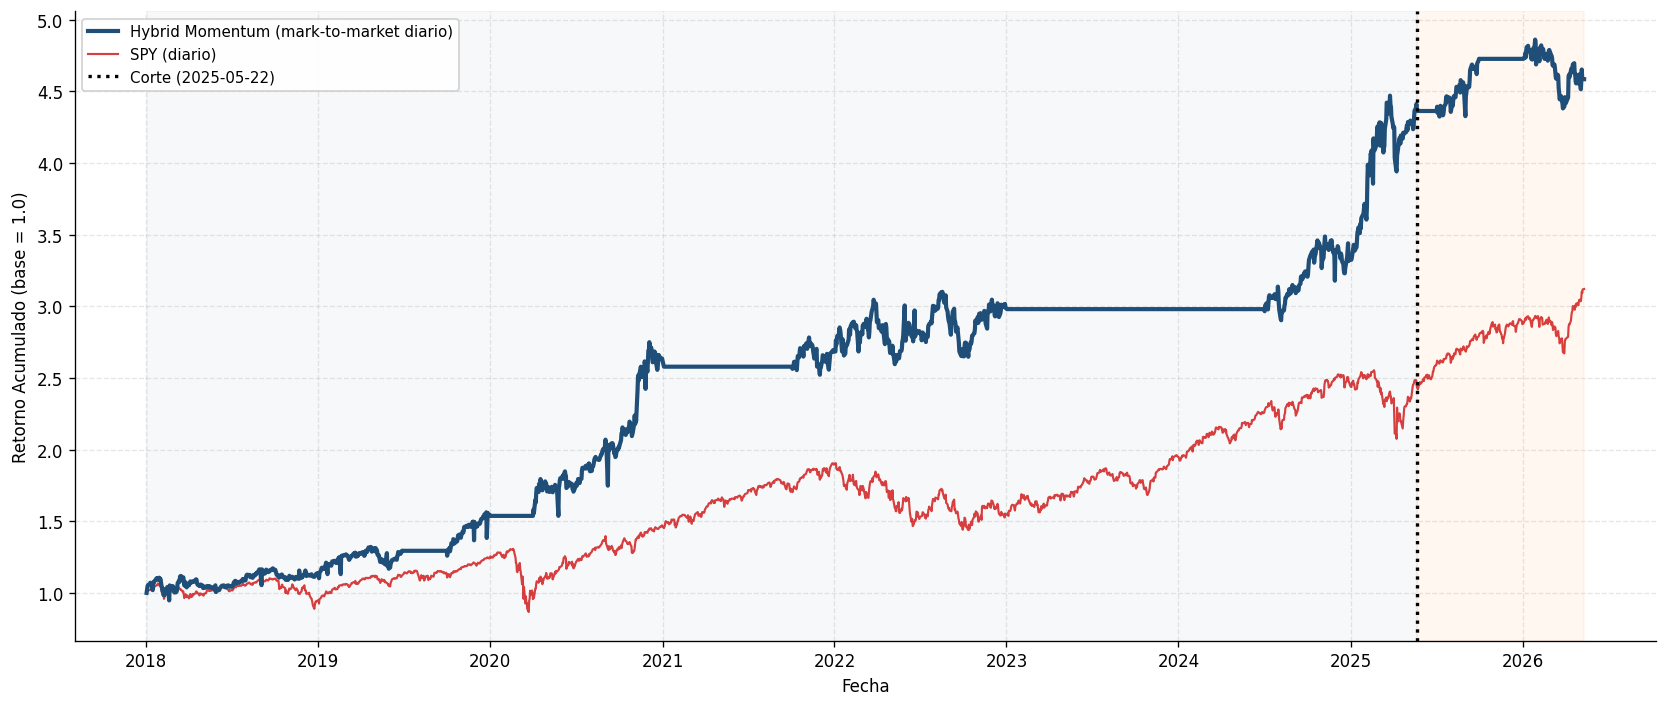

In [3]:
if df_wf is not None and not df_wf.empty:
    plot_equity_curve_with_split(rank=1, wf_results_df=df_wf,
        save=True, filename='wf_01_equity_curve_winner_daily.png')

## Grafica 2 — Scatter: Sharpe Train vs Sharpe Test

  [visualization] Guardado -> c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures\wf_02_sharpe_scatter.png


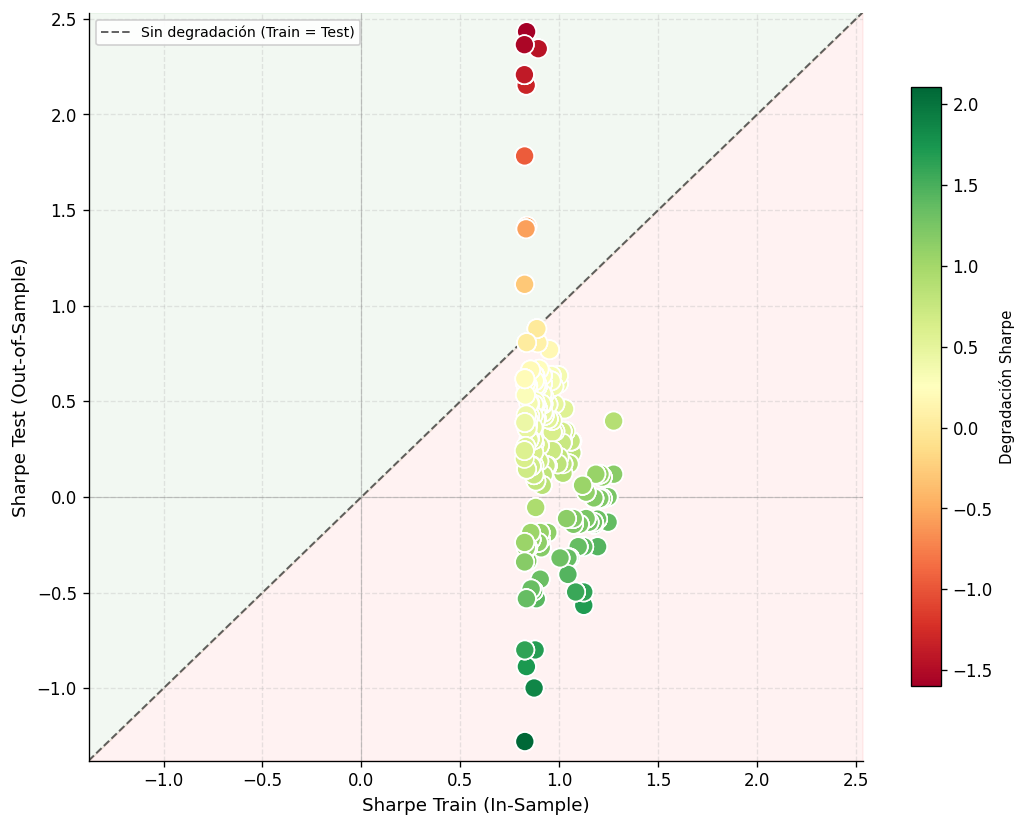

In [4]:
if df_wf is not None and not df_wf.empty:
    plot_sharpe_scatter(wf_df=df_wf, save=True, filename='wf_02_sharpe_scatter.png')

## Grafica 3 — Barras Sharpe Train vs Test por Configuracion

[visualization] Sección 6 — 636 configs válidas; mostrando top/bottom 25 por Sharpe_Train.
  [visualization] Guardado -> c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures\wf_03_degradation_bar.png


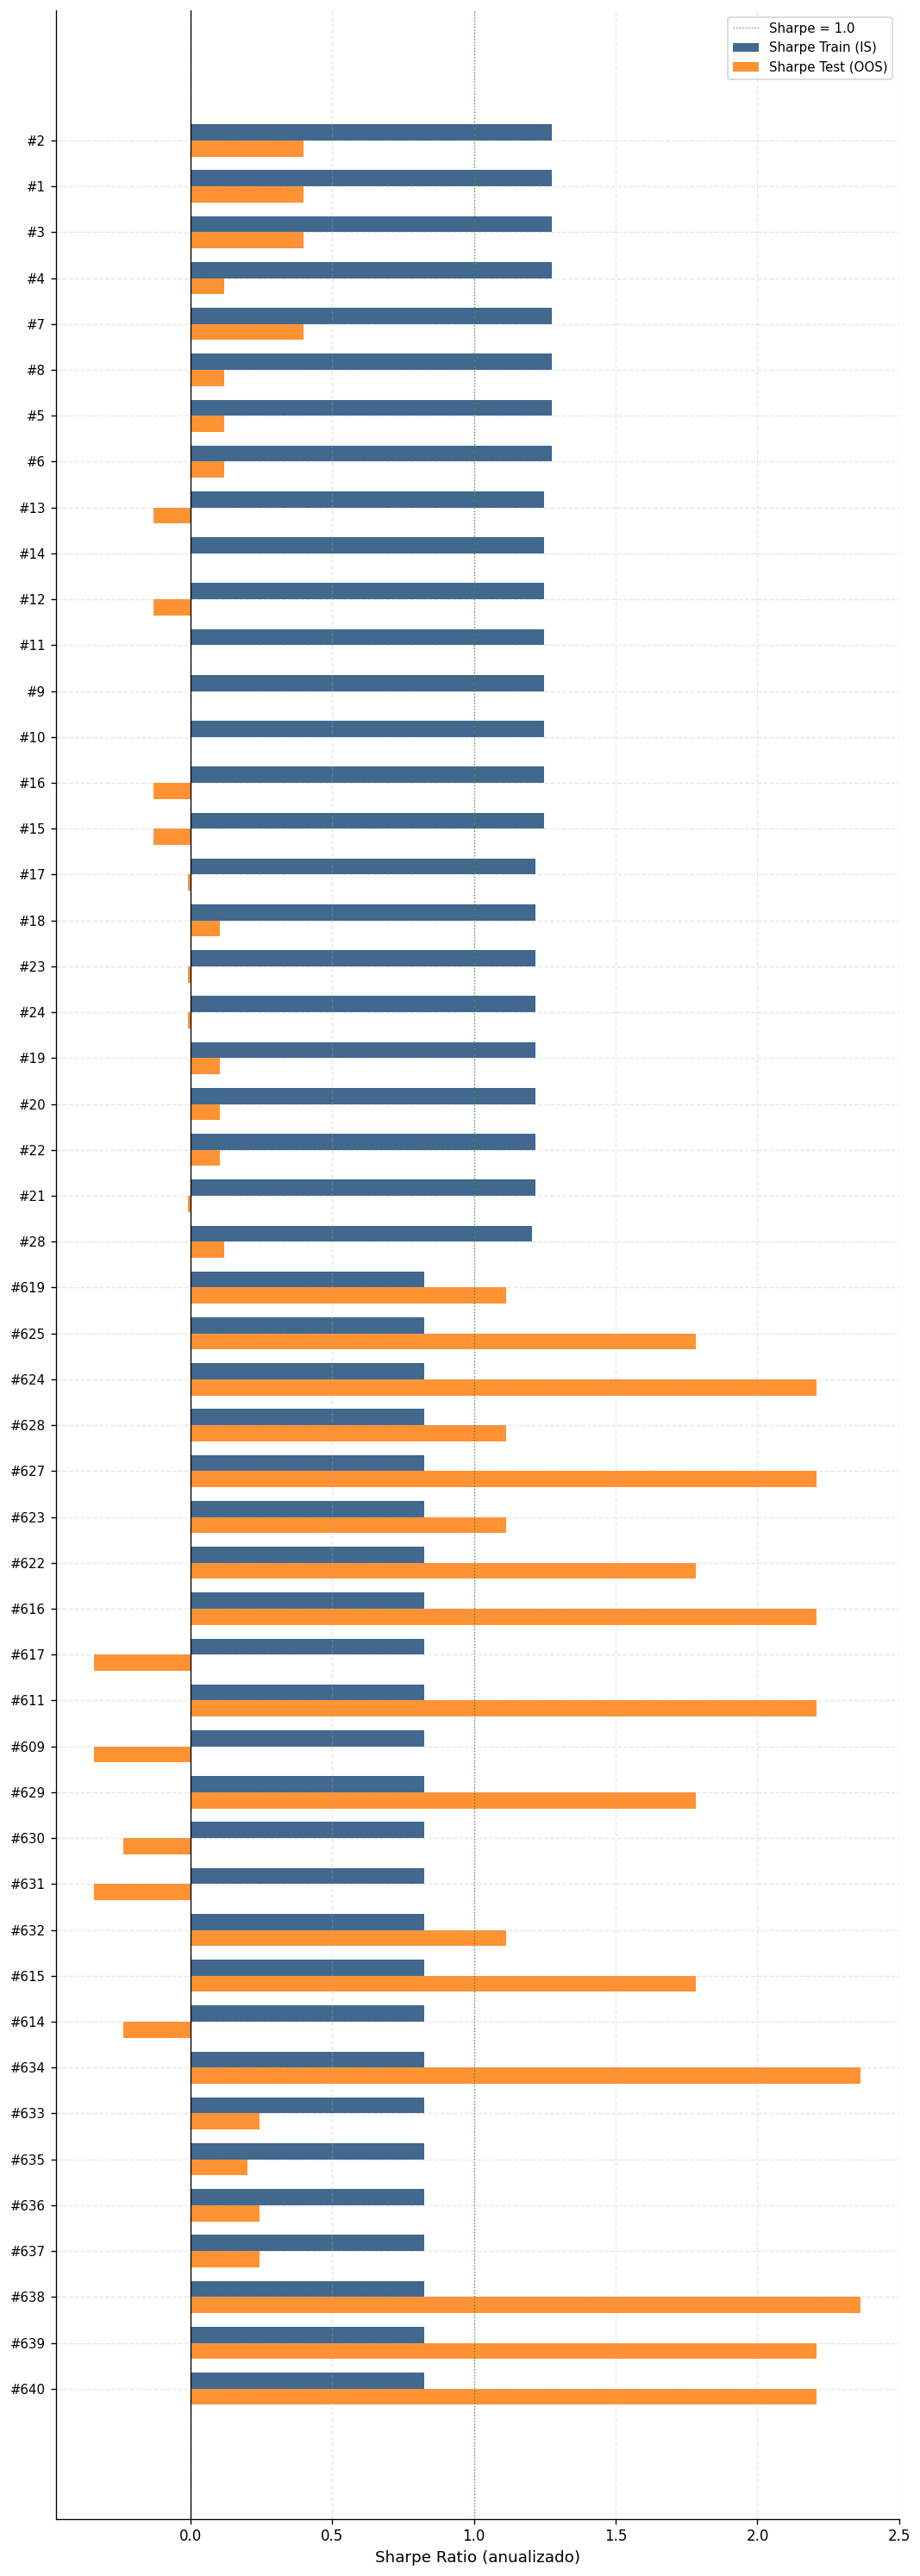

In [5]:
if df_wf is not None and not df_wf.empty:
    plot_degradation_bar(wf_df=df_wf, save=True, filename='wf_03_degradation_bar.png')

## Grafica 4 — Distribucion de Hiperparametros (Top 10 % por Sharpe_Test)

Solo las configuraciones con mayor Sharpe Out-of-Sample.

  [_top10pct_by_sharpe_test] Umbral Sharpe_Test >= 0.6350: 84/640 estrategias retenidas.
Top 10 % por Sharpe_Test: 84 configuraciones
  [_top10pct_by_sharpe_IS] Umbral Sharpe >= 0.8240: 648/6400 estrategias retenidas.
[visualization] Sección 5 — Top 10 % Grid IS por Sharpe (In-Sample): N=648
[visualization] Sección 5 — Coherencia de conteos (n_elite=648):
  [OK] top_n: conteos=648, NaN=0, total=648
  [OK] rebalance_freq: conteos=648, NaN=0, total=648
  [OK] anomaly_lookback_days: conteos=648, NaN=0, total=648
  [OK] momentum_signal: conteos=648, NaN=0, total=648
  [OK] active_cluster: conteos=648, NaN=0, total=648
  [OK] rank_weighted: conteos=648, NaN=0, total=648
  [OK] min_portfolio_size: conteos=648, NaN=0, total=648
  -> Todos los parámetros son matemáticamente coherentes.
  [visualization] Guardado -> c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures\wf_04_hyperparameter_distribution_oos.png  (Top 10 % Grid IS por Sharpe (In-Sample), N

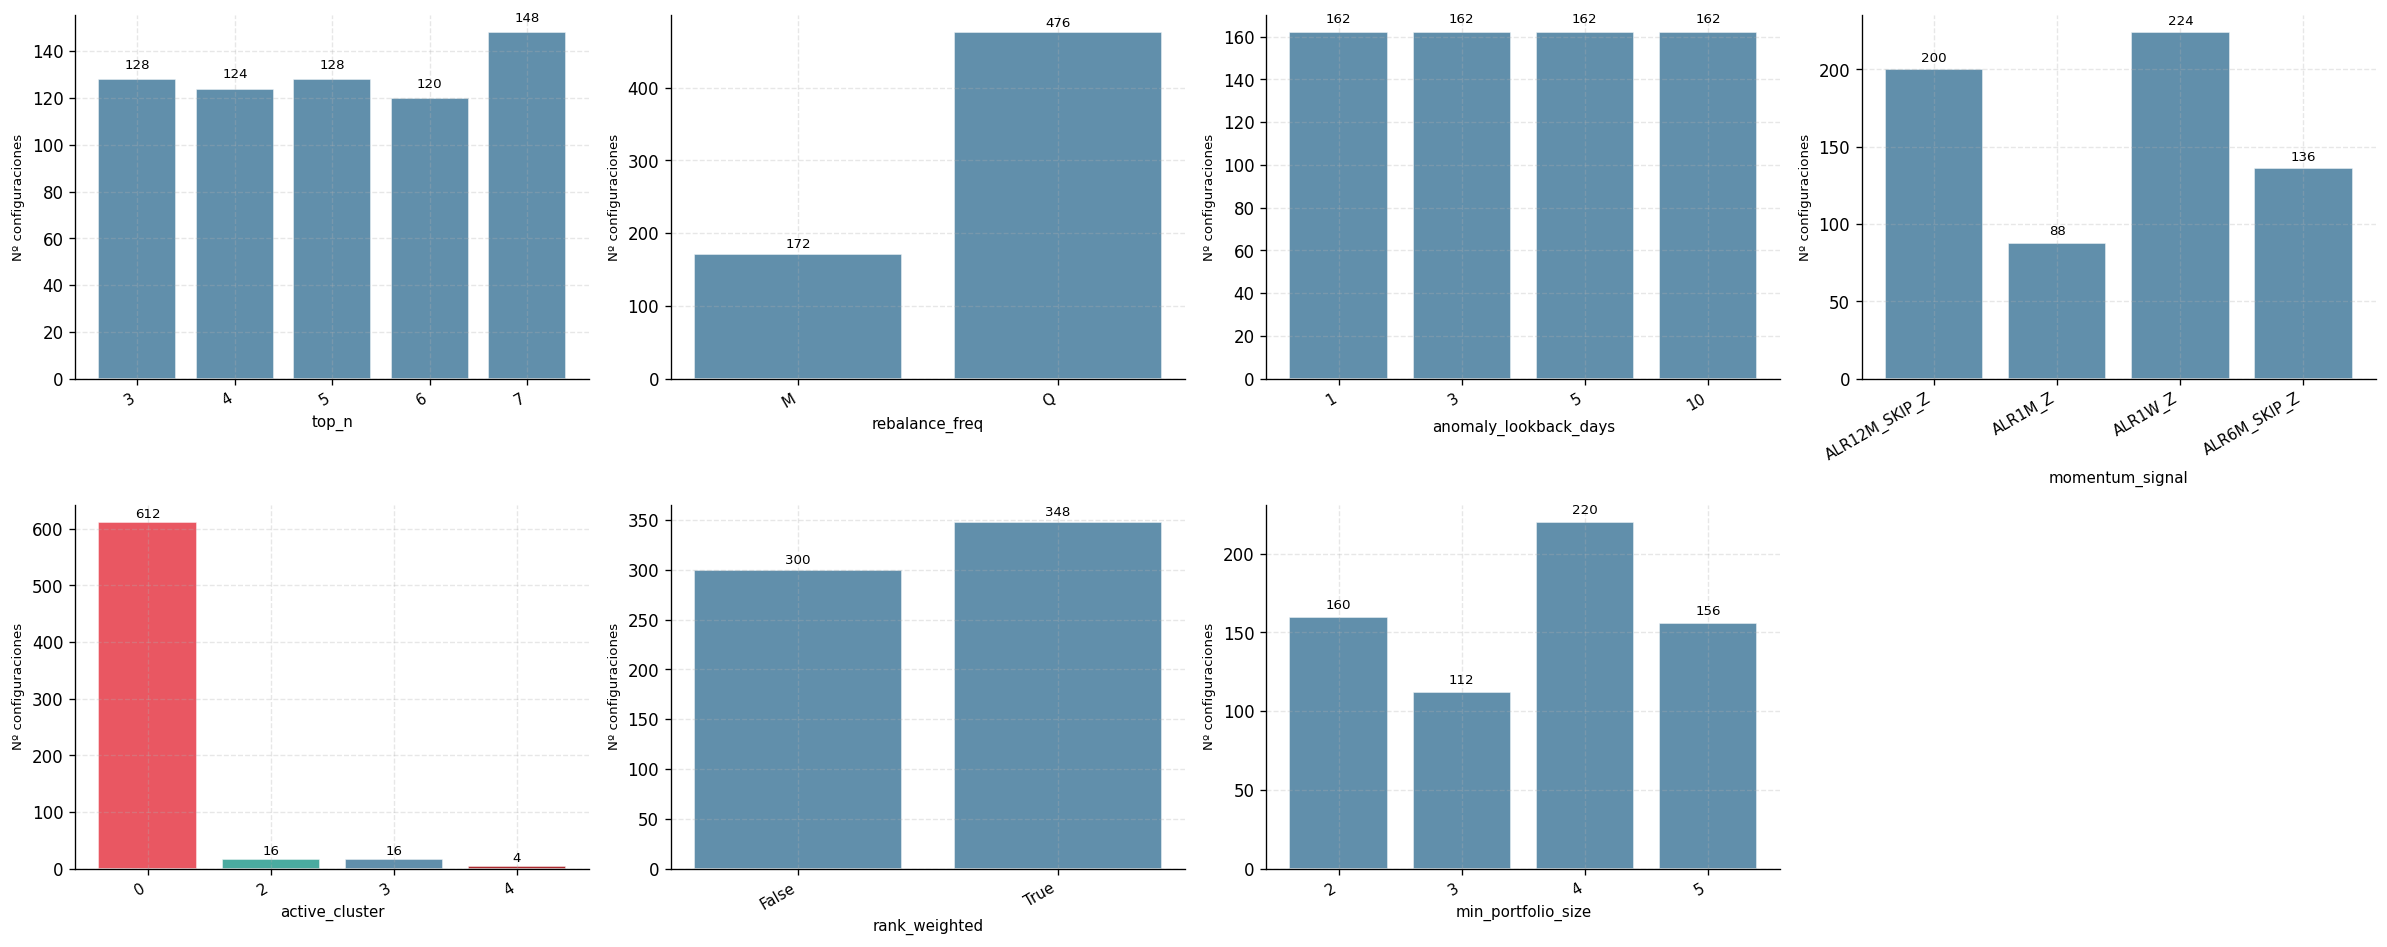

In [6]:
if df_wf is not None and not df_wf.empty:
    elite = _top10pct_by_sharpe_test(df_wf)
    print(f'Top 10 % por Sharpe_Test: {len(elite)} configuraciones')
    plot_hyperparameter_distribution(wf_df=df_wf, save=True,
        filename='wf_04_hyperparameter_distribution_oos.png')

## Grafica 5 — Distribucion de Sharpe del Grid Search completo

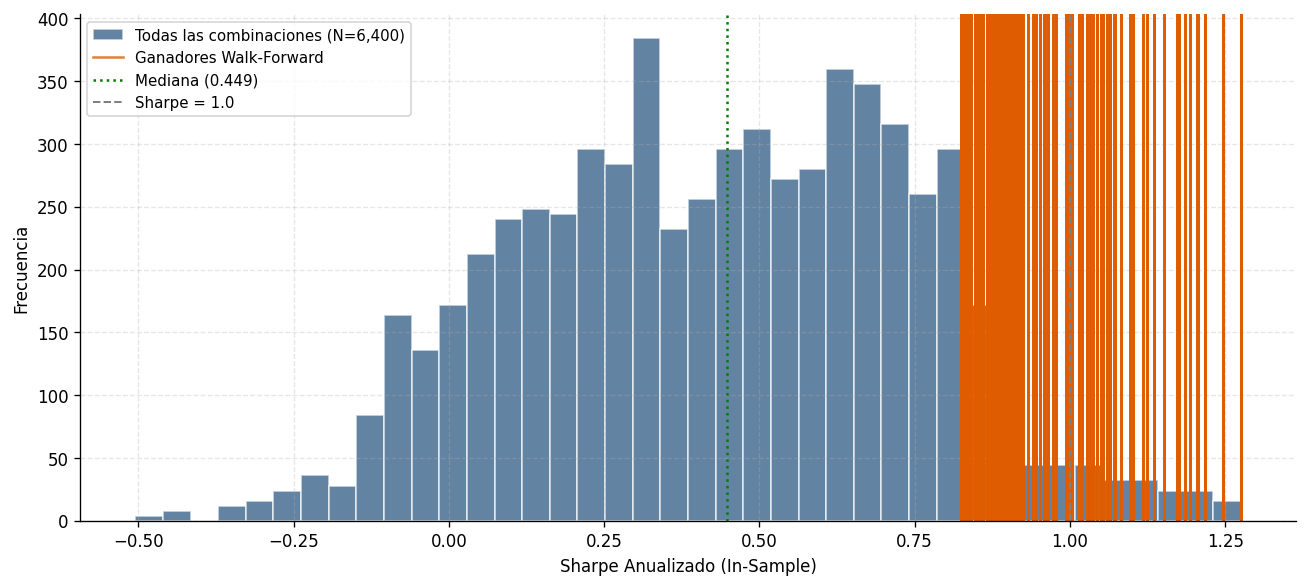

Guardado: c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures\wf_05_sharpe_distribution_grid.png


In [7]:
if df_grid is not None and not df_grid.empty and 'Sharpe' in df_grid.columns:
    sharpes = df_grid['Sharpe'].dropna()
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.hist(sharpes, bins=40, color=COLOR_TRAIN, alpha=0.7, edgecolor='white',
            label=f'Todas las combinaciones (N={len(sharpes):,})')
    if df_wf is not None and 'Sharpe_Train' in df_wf.columns:
        for i, s in enumerate(df_wf['Sharpe_Train'].dropna()):
            ax.axvline(x=s, color=COLOR_TEST, lw=1.5, alpha=0.8,
                       label='Ganadores Walk-Forward' if i == 0 else '_nolegend_')
    ax.axvline(x=sharpes.median(), color='green', lw=1.5, ls=':',
               label=f'Mediana ({sharpes.median():.3f})')
    ax.axvline(x=1.0, color='gray', lw=1.2, ls='--', label='Sharpe = 1.0')
    ax.set_xlabel('Sharpe Anualizado (In-Sample)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    out = os.path.join(DIR_FIGURES, 'wf_05_sharpe_distribution_grid.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out}')

## Grafica 6 — Sensibilidad OOS por Hiperparametro (Top 10 % Sharpe_Test)

> Puede tardar 1-2 minutos.

[visualization] Pool OOS para sensibilidad: 636 configuraciones
[visualization] Reconstruyendo curvas diarias OOS...
  [visualization] 636/636 curvas reconstruidas (0 fallidas).
  [visualization] Guardado -> c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures\wf_06_oos_parameter_sensitivity_top10pct.png


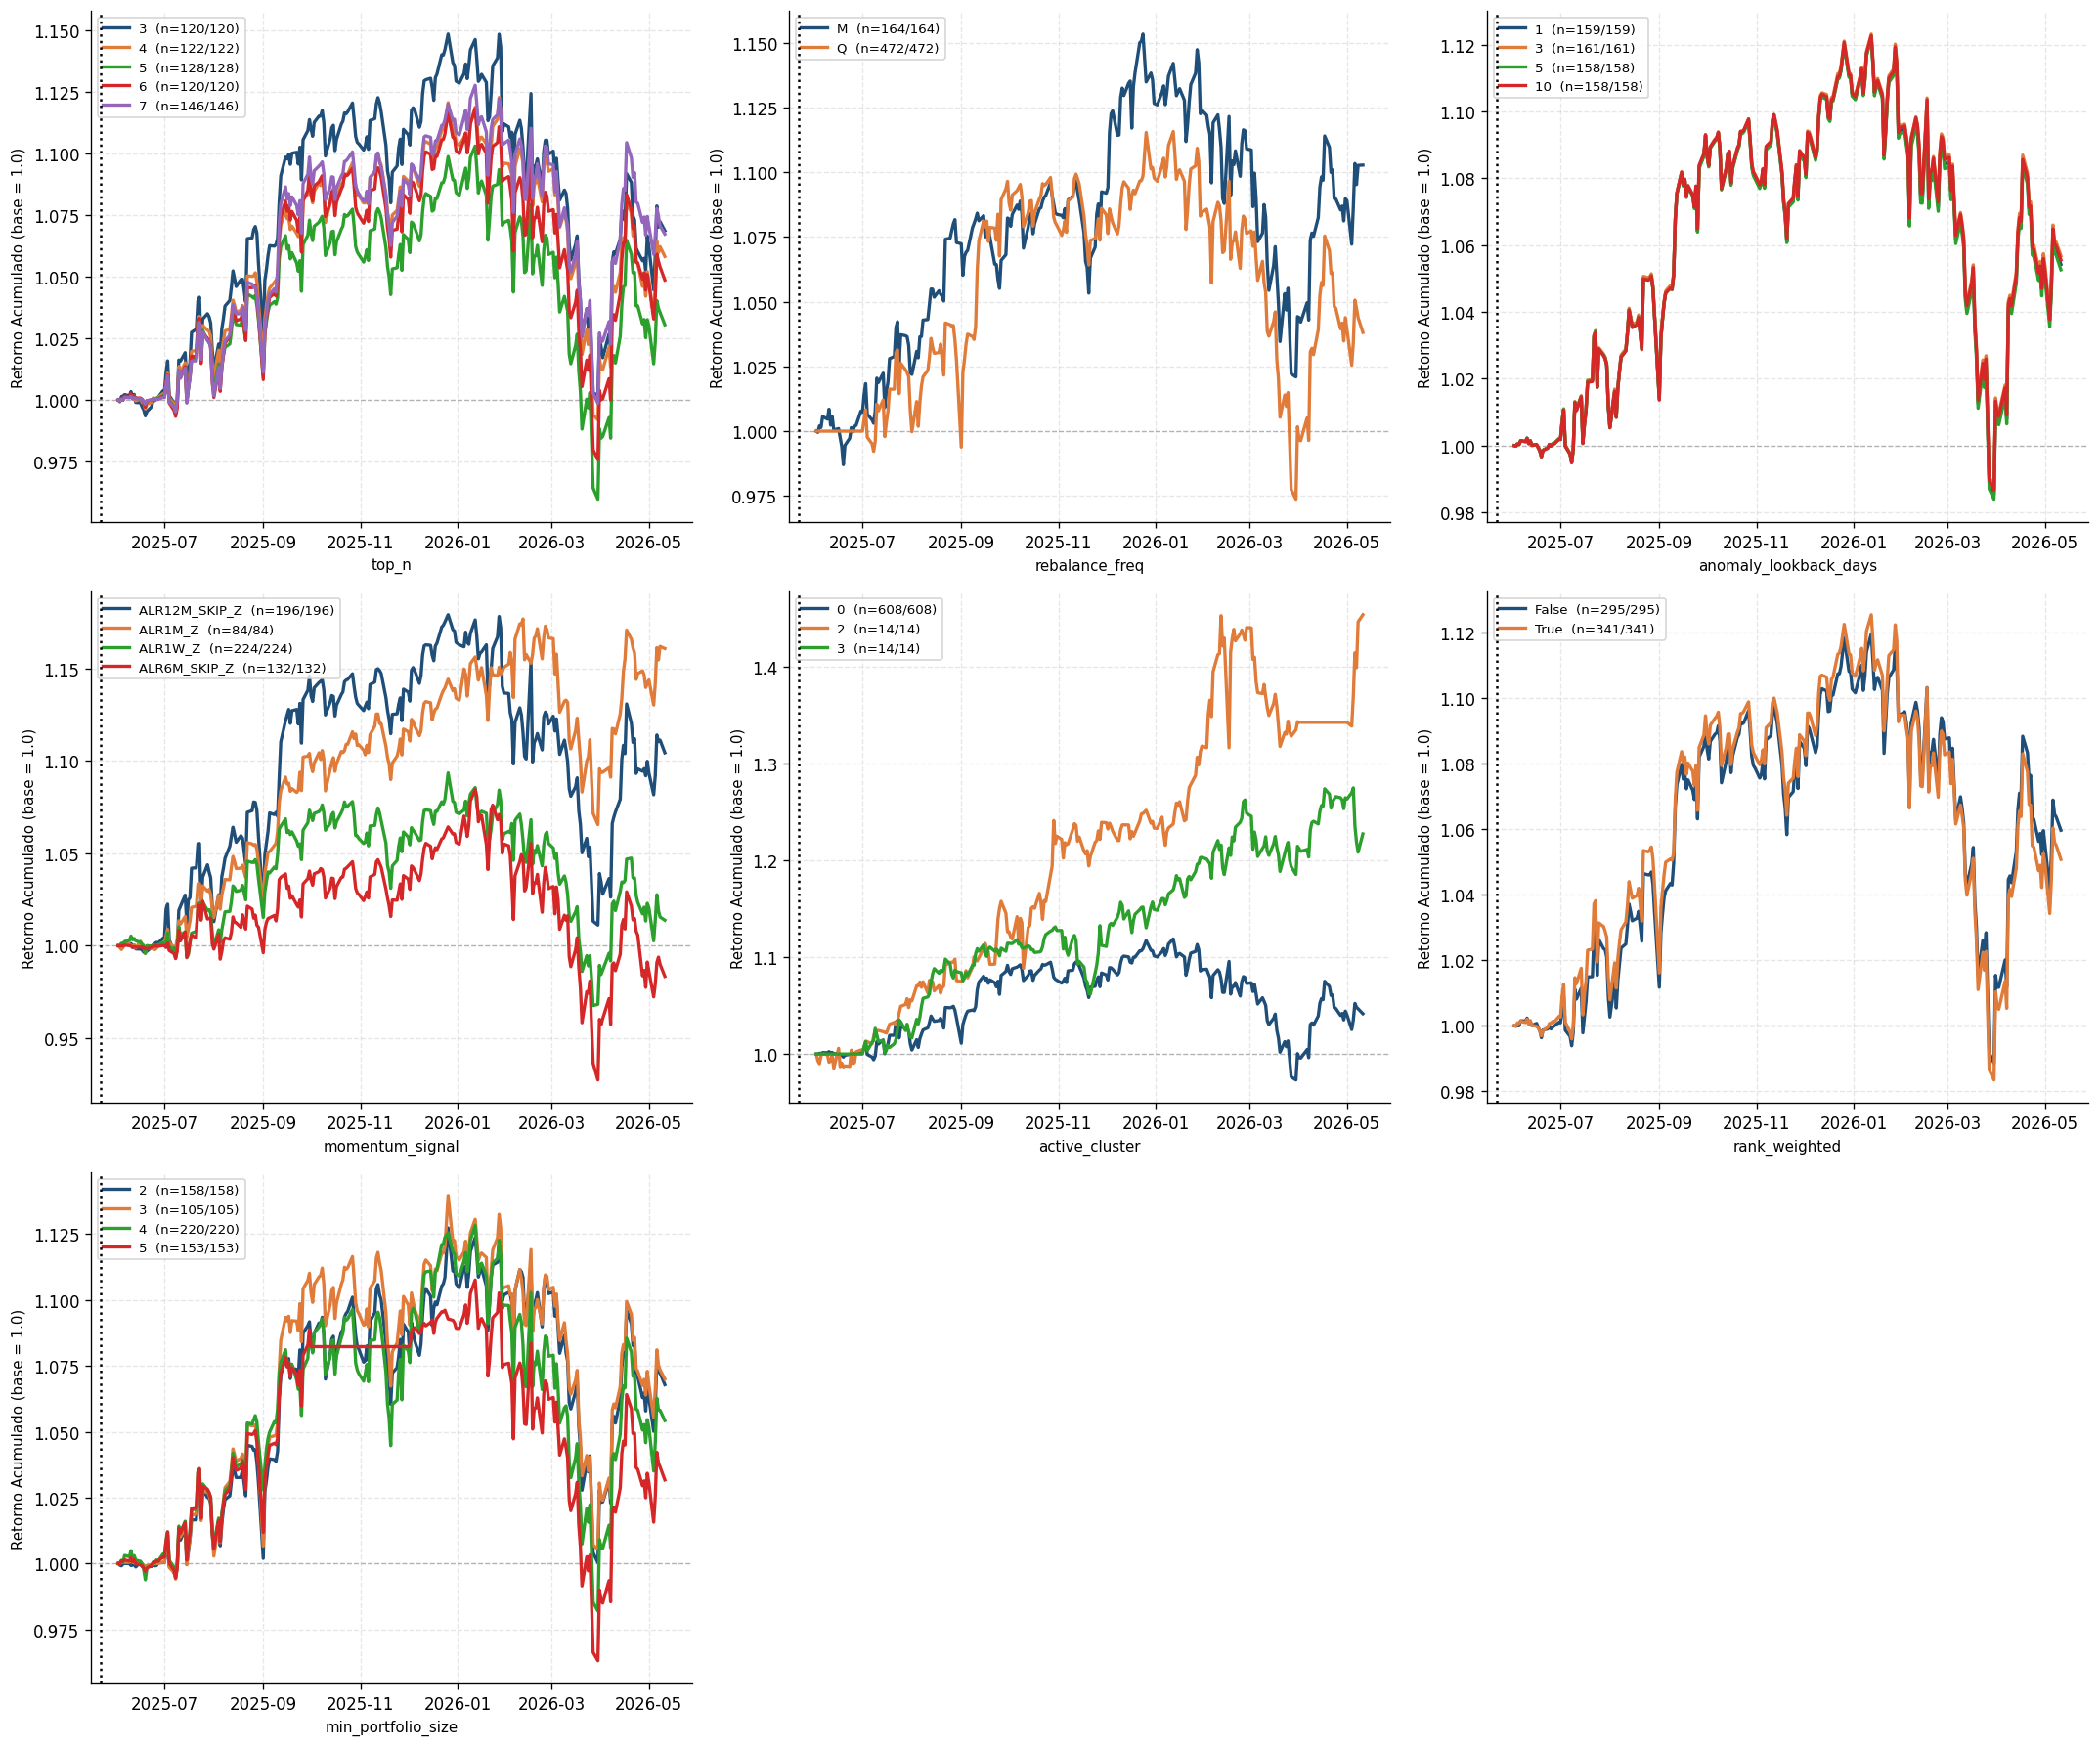

In [8]:
if df_wf is not None and not df_wf.empty:
    plot_oos_parameter_sensitivity(wf_df=df_wf, save=True,
        filename='wf_06_oos_parameter_sensitivity_top10pct.png')

## Tabla Resumen Walk-Forward

In [16]:
if df_wf is not None and not df_wf.empty:

    # =========================================================
    # RESUMEN GLOBAL
    # =========================================================

    print("=" * 70)
    print("RESUMEN WALK-FORWARD")
    print("=" * 70)

    print(f"Número de configuraciones: {len(df_wf)}")

    print(
        f"Sharpe Test medio: "
        f"{df_wf['Sharpe_Test'].mean():.3f}"
    )

    print(
        f"Sharpe Test máximo: "
        f"{df_wf['Sharpe_Test'].max():.3f}"
    )

    print(
        f"Sharpe Train medio: "
        f"{df_wf['Sharpe_Train'].mean():.3f}"
    )

    if 'Degradacion_Sharpe' in df_wf.columns:

        print(
            f"Degradación media: "
            f"{df_wf['Degradacion_Sharpe'].mean():+.3f}"
        )

    # =========================================================
    # TOP CONFIGS
    # =========================================================

    print("\n")
    print("=" * 70)
    print("TOP 10 CONFIGURACIONES OOS")
    print("=" * 70)

    cols_show = [
        'top_n',
        'rebalance_freq',
        'momentum_signal',
        'active_cluster',
        'Sharpe_Train',
        'Sharpe_Test',
        'Degradacion_Sharpe',
    ]

    top10 = (
        df_wf
        .sort_values(
            'Sharpe_Test',
            ascending=False
        )
        .head(10)
    )

    display(
        top10[cols_show]
        .style
        .format({
            'Sharpe_Train': '{:.3f}',
            'Sharpe_Test': '{:.3f}',
            'Degradacion_Sharpe': '{:+.3f}',
        })
        .background_gradient(
            subset=['Sharpe_Test'],
            cmap='RdYlGn'
        )
    )

RESUMEN WALK-FORWARD
Número de configuraciones: 640
Sharpe Test medio: 0.266
Sharpe Test máximo: 2.433
Sharpe Train medio: 0.947
Degradación media: +0.682


TOP 10 CONFIGURACIONES OOS


,top_n,rebalance_freq,momentum_signal,active_cluster,Sharpe_Train,Sharpe_Test,Degradacion_Sharpe
545,4,M,ALR1M_Z,2,0.835,2.433,-1.598
543,4,M,ALR1M_Z,2,0.835,2.433,-1.598
548,4,M,ALR1M_Z,2,0.835,2.433,-1.598
541,4,M,ALR1M_Z,2,0.835,2.433,-1.598
637,4,M,ALR1M_Z,2,0.824,2.365,-1.541
633,4,M,ALR1M_Z,2,0.824,2.365,-1.541
338,4,M,ALR1M_Z,2,0.894,2.344,-1.450
335,4,M,ALR1M_Z,2,0.894,2.344,-1.450
334,4,M,ALR1M_Z,2,0.894,2.344,-1.450
332,4,M,ALR1M_Z,2,0.894,2.344,-1.450


In [18]:
if df_wf is not None and not df_wf.empty:
    print(df_wf.columns.tolist())
    summary_cols = ['rank_train','Sharpe_Train','Sharpe_Test', 'Degradacion_Sharpe',#'Sharpe_Degradation_%',
                    #'CAGR_Train_%','CAGR_Test_%','MaxDD_Train_%','MaxDD_Test_%']
                    'CAGR_Train (%)', 'CAGR_Test (%)', 'MaxDD_Train (%)', 'MaxDD_Test (%)']
    avail = [c for c in summary_cols if c in df_wf.columns]
    try:
        styled = (
            df_wf[avail].style
            .format({'Sharpe_Train':'{:.3f}','Sharpe_Test':'{:.3f}',
                     'Sharpe_Degradation_%':'{:+.1f}%','CAGR_Train_%':'{:.1f}%',
                     'CAGR_Test_%':'{:.1f}%','MaxDD_Train_%':'{:.1f}%',
                     'MaxDD_Test_%':'{:.1f}%'}, na_rep='N/A')
            .background_gradient(subset=['Sharpe_Test'], cmap='RdYlGn')
            .background_gradient(subset=['Degradacion_Sharpe'#'Sharpe_Degradation_%'
                                         ], cmap='RdYlGn_r')
        )
        display(styled)
    except Exception:
        print(df_wf[avail].to_string(index=False))
    if 'Sharpe_Test' in df_wf.columns:
        vt = df_wf['Sharpe_Test'].dropna()
        print(f'Sharpe Test: media={vt.mean():.3f} | max={vt.max():.3f}')
    if 'Degradacion_Sharpe' in df_wf.columns:
        vd = df_wf['Degradacion_Sharpe'#'Sharpe_Degradation_%'
                   ].dropna()
        print(f'Degradacion media: {vd.mean():+.1f}% | {(vd>0).sum()}/{len(vd)} configs mejoran')

['rank_insample', 'top_n', 'rebalance_freq', 'anomaly_lookback_days', 'momentum_signal', 'active_cluster', 'rank_weighted', 'min_portfolio_size', 'Sharpe_Train', 'Sharpe_Test', 'Degradacion_Sharpe', 'CAGR_Train (%)', 'CAGR_Test (%)', 'MaxDD_Train (%)', 'MaxDD_Test (%)']


,Sharpe_Train,Sharpe_Test,Degradacion_Sharpe,CAGR_Train (%),CAGR_Test (%),MaxDD_Train (%),MaxDD_Test (%)
0,1.275,0.397,0.878000,21.880000,5.090000,-8.250000,-6.510000
1,1.275,0.397,0.878000,21.880000,5.090000,-8.250000,-6.510000
2,1.275,0.397,0.878000,21.880000,5.090000,-8.250000,-6.510000
3,1.275,0.119,1.156000,21.880000,1.610000,-8.250000,-9.610000
4,1.275,0.119,1.156000,21.880000,1.610000,-8.250000,-9.610000
5,1.275,0.119,1.156000,21.880000,1.610000,-8.250000,-9.610000
6,1.275,0.397,0.878000,21.880000,5.090000,-8.250000,-6.510000
7,1.275,0.119,1.156000,21.880000,1.610000,-8.250000,-9.610000
8,1.247,0.001,1.246000,20.360000,0.020000,-8.980000,-8.140000
9,1.247,0.001,1.246000,20.360000,0.020000,-8.980000,-8.140000


Sharpe Test: media=0.266 | max=2.433
Degradacion media: +0.7% | 600/636 configs mejoran


In [10]:
import glob
figuras = sorted(glob.glob(os.path.join(DIR_FIGURES, 'wf_*.png')))
print(f'Figuras en {DIR_FIGURES}:')
for f in figuras:
    print(f'  {os.path.basename(f):55s} {os.path.getsize(f)/1024:6.1f} KB')

Figuras en c:\Users\marce\Desktop\UNIR\TFM\Proyecto\git\hybrid-momentum-anomaly-detection\results\figures:
  wf_01_equity_curve_winner_daily.png                      147.6 KB
  wf_02_sharpe_scatter.png                                 132.3 KB
  wf_03_degradation_bar.png                                177.2 KB
  wf_04_hyperparameter_distribution_oos.png                159.0 KB
  wf_05_sharpe_distribution_grid.png                        68.0 KB
  wf_06_oos_parameter_sensitivity_top10pct.png             823.9 KB


# Análisis de Robustez de Hiperparámetros

El objetivo de este análisis no es identificar una única configuración óptima, sino estudiar qué combinaciones de parámetros producen resultados robustos Out-of-Sample (OOS).

Para ello se analizan:

- estadísticas agregadas por parámetro
- importancia relativa de cada hiperparámetro
- configuraciones robustas
- y frecuencia de aparición de valores en las mejores estrategias OOS

La función `parameter_summary()` agrupa las estrategias por cada valor de un hiperparámetro y calcula:

- media de `Sharpe_Test`
- mediana
- desviación estándar
- máximo alcanzado
- número de configuraciones evaluadas

Esto permite detectar patrones consistentes y no depender únicamente de una estrategia aislada.

In [11]:
from analysis.parameter_analysis import (
    parameter_summary,
)

params = [
    "top_n",
    "rebalance_freq",
    "anomaly_lookback_days",
    "momentum_signal",
    "active_cluster",
    "rank_weighted",
    "min_portfolio_size",
]

for p in params:

    print("\n")
    print("=" * 70)
    print(p)
    print("=" * 70)

    display(
        parameter_summary(df_wf, p)
    )



top_n


,mean,median,std,max,count
top_n,,,,,
7,0.447644,0.3640,0.561196,2.208,146
6,0.292267,0.2990,0.345975,1.112,120
3,0.280825,0.2080,0.486774,2.153,120
4,0.174607,0.1630,0.816514,2.433,122
5,0.107219,0.1375,0.494369,1.415,128




rebalance_freq


,mean,median,std,max,count
rebalance_freq,,,,,
M,0.696787,0.407,0.710359,2.433,164
Q,0.116271,0.173,0.426612,0.635,472




anomaly_lookback_days


...

,mean,median,std,max,count
active_cluster,,,,,
2,2.317857,2.344,0.113991,2.433,14
3,1.856286,1.783,0.349637,2.208,14
0,0.182097,0.266,0.422986,1.415,608
4,NaN,NaN,NaN,NaN,0




rank_weighted


,mean,median,std,max,count
rank_weighted,,,,,
False,0.316044,0.278,0.626247,2.433,295
True,0.222639,0.299,0.521047,2.365,341




min_portfolio_size


,mean,median,std,max,count
min_portfolio_size,,,,,
3,0.334952,0.242,0.644026,2.433,105
4,0.313673,0.344,0.487806,2.208,220
2,0.297380,0.292,0.719156,2.365,158
5,0.117575,0.233,0.429330,0.668,153


## Interpretación de resultados

### `top_n`

Los mejores resultados OOS aparecen principalmente con:

- `top_n = 7`
- seguido de `top_n = 6` y `top_n = 3`

Mientras que `top_n = 5` muestra el peor rendimiento medio.

Esto sugiere que carteras ligeramente más diversificadas presentan mayor estabilidad OOS.

---

### `rebalance_freq`

El rebalanceo mensual (`M`) domina claramente frente al trimestral (`Q`):

- media Sharpe_Test:
  - Monthly ≈ 0.70
  - Quarterly ≈ 0.12

Esto indica que la estrategia depende significativamente de una actualización frecuente de señales.

---

### `anomaly_lookback_days`

Las diferencias entre ventanas de anomalía son pequeñas.

Todos los valores generan resultados similares:

- 1 día
- 3 días
- 5 días
- 10 días

La importancia de este parámetro parece reducida.

---

### `momentum_signal`

Es uno de los parámetros más determinantes.

La señal:

- `ALR1M_Z`

presenta claramente el mejor rendimiento OOS.

Mientras que:

- `ALR6M_SKIP_Z`

muestra resultados negativos en promedio.

Esto sugiere que señales de momentum más rápidas funcionan mejor bajo este framework híbrido.

---

### `active_cluster`

Los clusters:

- `2`
- `3`

obtienen resultados extremadamente altos.

Sin embargo:

- tienen muy pocas observaciones (`count=14`)

Por tanto, aunque parecen prometedores, podrían reflejar sobreajuste o poca robustez estadística.

El cluster `0` es el único realmente representativo del universo completo.

---

### `rank_weighted`

Las configuraciones sin weighting (`False`) presentan mejores resultados medios OOS que las ponderadas (`True`).

Esto sugiere que introducir weighting adicional no mejora la generalización.

---

### `min_portfolio_size`

Los mejores resultados aparecen con:

- `3`
- `4`

Mientras que tamaños mínimos mayores degradan el rendimiento.


In [12]:
from analysis.parameter_analysis import (
    compute_feature_importance,
)

importance_df = compute_feature_importance(
    df_wf,
    params,
)

importance_df

,Variable,Importance
4,active_cluster,0.460022
3,momentum_signal,0.280287
1,rebalance_freq,0.092453
0,top_n,0.091886
5,rank_weighted,0.058607
6,min_portfolio_size,0.016474
2,anomaly_lookback_days,0.000270


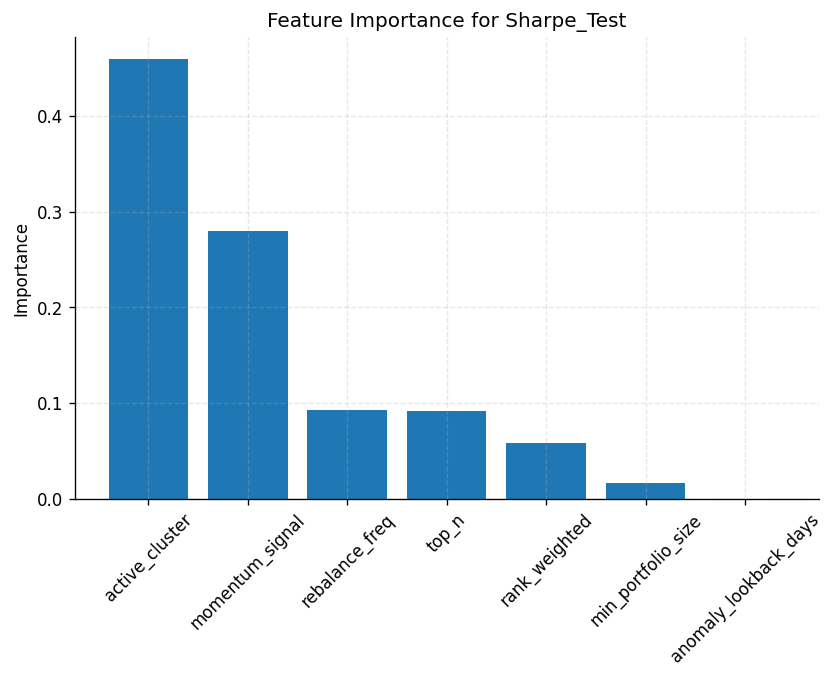

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Variable"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.ylabel("Importance")

plt.title("Feature Importance for Sharpe_Test")

plt.show()

La función `get_robust_configurations()` selecciona estrategias con:

- Sharpe_Test alto,
- y degradación limitada entre Train y Test.

El objetivo es identificar configuraciones que generalicen bien Out-of-Sample.

In [14]:
from analysis.parameter_analysis import (
    get_robust_configurations,
)

robust = get_robust_configurations(
    df_wf,
    min_sharpe=0.5,
    max_degradation=0.5,
)

robust.head(20)

,rank_insample,top_n,rebalance_freq,anomaly_lookback_days,momentum_signal,active_cluster,rank_weighted,min_portfolio_size,Sharpe_Train,Sharpe_Test,Degradacion_Sharpe,CAGR_Train (%),CAGR_Test (%),MaxDD_Train (%),MaxDD_Test (%)
548,549,4,M,3,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
545,546,4,M,1,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
543,544,4,M,10,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
541,542,4,M,5,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
633,634,4,M,10,ALR1M_Z,2,True,2,0.824,2.365,-1.541,15.11,49.86,-24.40,-7.25
637,638,4,M,3,ALR1M_Z,2,True,2,0.824,2.365,-1.541,15.11,49.86,-24.40,-7.25
335,336,4,M,3,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
338,339,4,M,1,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
332,333,4,M,5,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
334,335,4,M,10,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46


Las mejores configuraciones robustas comparten varios patrones:

- rebalanceo mensual (`M`)
- momentum `ALR1M_Z`
- clusters `2` y `3`
- `top_n` entre `3` y `7`
- `rank_weighted=False`

Además:

- los resultados OOS superan claramente los IS,
- lo que produce degradación negativa.

Esto es especialmente interesante porque indica mejora OOS en vez de deterioro.

No obstante, debe interpretarse con cautela debido al bajo número de observaciones de ciertos clusters.

# Frecuencia de Valores en el Top OOS

La función `top_value_frequencies()` analiza qué valores aparecen con más frecuencia entre las mejores estrategias OOS.

Este análisis es especialmente relevante porque permite identificar patrones recurrentes y no una única configuración aislada.

In [15]:
from analysis.parameter_analysis import (
    top_value_frequencies,
)

freqs = top_value_frequencies(
    df_wf,
    params,
    top_n=50
)

for p, f in freqs.items():

    print("\n")
    print("=" * 70)
    print(p)
    print("=" * 70)

    display(f)



top_n


top_n
7    0.48
4    0.20
6    0.16
3    0.08
5    0.08
Name: proportion, dtype: float64



rebalance_freq


rebalance_freq
M    1.0
Name: proportion, dtype: float64



anomaly_lookback_days


...

active_cluster
0    0.44
2    0.28
3    0.28
Name: proportion, dtype: float64



rank_weighted


rank_weighted
False    0.68
True     0.32
Name: proportion, dtype: float64



min_portfolio_size


min_portfolio_size
4    0.52
2    0.28
3    0.20
Name: proportion, dtype: float64

## Resultados principales

### `rebalance_freq`

- `M` aparece en el 100 % del Top 50.

Resultado extremadamente sólido.

---

### `top_n`

- `7` aparece en el 48 % de las mejores configuraciones.

Muy dominante frente al resto.

---

### `momentum_signal`

- `ALR1M_Z` aparece en el 56 % del Top 50.

Confirmando los resultados observados previamente.

---

### `rank_weighted`

- `False` aparece en el 68 % del Top 50.

---

### `min_portfolio_size`

- `4` aparece en el 52 % de las configuraciones top.


# Conclusión General

El análisis muestra que las configuraciones robustas OOS tienden a compartir:

- rebalanceo mensual
- señales de momentum rápidas (`ALR1M_Z`)
- carteras relativamente diversificadas (`top_n 7`)
- ausencia de weighting adicional
- y tamaños mínimos de cartera moderados (`3-4`)

Además, el estudio demuestra que no existe una única configuración ganadora, sino patrones estructurales repetidos entre las mejores estrategias OOS.

Esto proporciona evidencia mucho más robusta, sólida y explicable que simplemente reportar la mejor simulación individual.